# ML Prediction Pipeline — Notebook 02: Exploratory Data Analysis

**Project:** Dubai Residential Property Price Prediction
**Notebook:** 02 — EDA
**Author:** Faiha
**Date:** 2026-08-01
**Description:** Explores `data/processed/clean_secondary_sales.csv` to understand the target variable, individual features, and the relationships between them, before any feature engineering or modeling is attempted.

**Currency note:** the target variable `price_usd` is reported in **USD** and is kept in USD throughout this project (see `docs/decisions.md`, decision 0001). Every price axis, title, and written observation in this notebook states USD explicitly so nothing is ambiguously read as AED.


## Objectives

This notebook answers the following questions, each with a visualization and a written observation:

1. What does the distribution of `price_usd` look like, and does a log transform    normalize it meaningfully for later modeling?
2. Which property types, locations, and furnishing levels command the highest and    lowest prices?
3. How do size (`area_sqft`) and bedroom count relate to price, and is that    relationship linear?
4. Does floor position matter within apartment buildings?
5. Which numeric features correlate most strongly with `price_usd`, and which    correlations are trivial (i.e. derived directly from the target) rather than    informative?
6. Does the effect of size/type on price differ by location, and vice versa    (multivariate interactions)?
7. What patterns, if generalized, would matter for a real Dubai property buyer or    seller?

**Two blueprint items are not directly available in this dataset** and are handled as follows:
- **Developer/building** — `secondary_sales.csv` has no `developer` column (that   field only exists in the separate, out-of-scope `off_plan.csv`). `condition`   (vacant_on_transfer / tenanted / off_plan_resale) is used as the closest available   substitute categorical dimension.
- **Bathrooms** — there is no `bathrooms` column in this dataset at all. This is   flagged explicitly rather than fabricated; bedroom count and area are used as the   available proxies for property size/specification.

**Explicitly out of scope for this notebook:** feature engineering, feature selection, encoding, scaling, and modeling. Any derived quantity computed below (e.g. `log_price`, `floor_ratio`) exists only as a transient plotting variable and is not persisted to any saved file — that happens in `03_modeling.ipynb`.


In [1]:
# --- Imports (all together, per project convention) ---
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Configuration ---
RANDOM_STATE = 42  # defined for pipeline consistency; only used below for the pairplot sample
DATA_PATH = Path("../data/processed/clean_secondary_sales.csv")
IMAGES_DIR = Path("../images")

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
PRICE_LABEL = "Price (USD)"


## 2. Load Cleaned Dataset

We load the output of `01_data_cleaning.ipynb` only — never the raw file — to keep this notebook dependent on the documented cleaning phase rather than re-deriving it.


In [2]:
df = pd.read_csv(DATA_PATH)
df["date_listed"] = pd.to_datetime(df["date_listed"])

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Shape: 50,000 rows x 29 columns


## 3. Dataset Overview


In [3]:
df.dtypes


id                                     str
date_listed                 datetime64[us]
community                              str
zone                                   str
is_freehold                           bool
lat                                float64
lon                                float64
property_category                      str
property_type                          str
bedrooms                             int64
area_sqft                            int64
area_m2                            float64
floor                              float64
total_floors                       float64
year_built                           int64
view                                   str
furnishing                             str
condition                              str
parking_spaces                       int64
chiller_included                      bool
metro_station                          str
metro_line                             str
metro_distance_min                   int64
metro_dista

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
date_listed,50000,2023-03-05 11:22:31.871999,2020-01-01 00:00:00,2021-08-05 00:00:00,2023-03-06 00:00:00,2024-10-05 00:00:00,2026-04-29 00:00:00,NaN
lat,50000.0,25.109746,24.88559,25.042047,25.07818,25.19833,25.31948,0.093276
lon,50000.0,55.25015,55.06197,55.18458,55.25522,55.294905,55.52416,0.077088
bedrooms,50000.0,2.54916,0.0,1.0,3.0,4.0,6.0,1.636544
area_sqft,50000.0,2243.502,300.0,795.0,1516.0,3311.25,13009.0,1816.580581
area_m2,50000.0,208.428206,27.9,73.9,140.9,307.625,1208.5,168.765302
floor,32180.0,21.652579,1.0,9.0,18.0,30.0,80.0,15.960796
total_floors,32180.0,42.413766,20.0,30.0,45.0,45.0,80.0,17.717616
year_built,50000.0,2016.29624,2008.0,2012.0,2018.0,2018.0,2023.0,4.308361
parking_spaces,50000.0,1.89676,1.0,1.0,2.0,2.0,4.0,0.930999


In [5]:
df.describe(include="object").T


/var/folders/z8/9v97z7tn00l_k4r0mp779xc80000gn/T/ipykernel_6967/3164331651.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
id,50000,50000,S000001,1
community,50000,84,DAMAC Lagoons,653
zone,50000,52,Jumeirah,4801
property_category,50000,2,apartment,32180
property_type,50000,9,1BR,10190
view,50000,8,community,15735
furnishing,50000,3,unfurnished,27594
condition,50000,3,vacant_on_transfer,27586
metro_station,50000,55,Dubai Internet City,2257
metro_line,50000,2,Red,39653


**Observations:**
- 50,000 rows, 29 columns, matching the cleaned dataset exactly — no rows were lost   between the cleaning and EDA phases.
- `price_usd` ranges from \$21,300 to \$24,501,200 with a median of \$593,700 — a   huge range that already hints at strong skew, examined in detail next.
- `area_sqft` ranges 300–13,009 sqft (median 1,516), consistent with a mix of   studios through large villas.
- Categorical columns show `community` (84 unique) and `zone` (52 unique) as the   highest-cardinality features — relevant later for how they're encoded/tiered in   the modeling phase.


## 4. Target Variable Analysis — `price_usd`

We analyze the target **before** touching any feature, per standard EDA practice: understanding what we're predicting shapes every decision that follows.


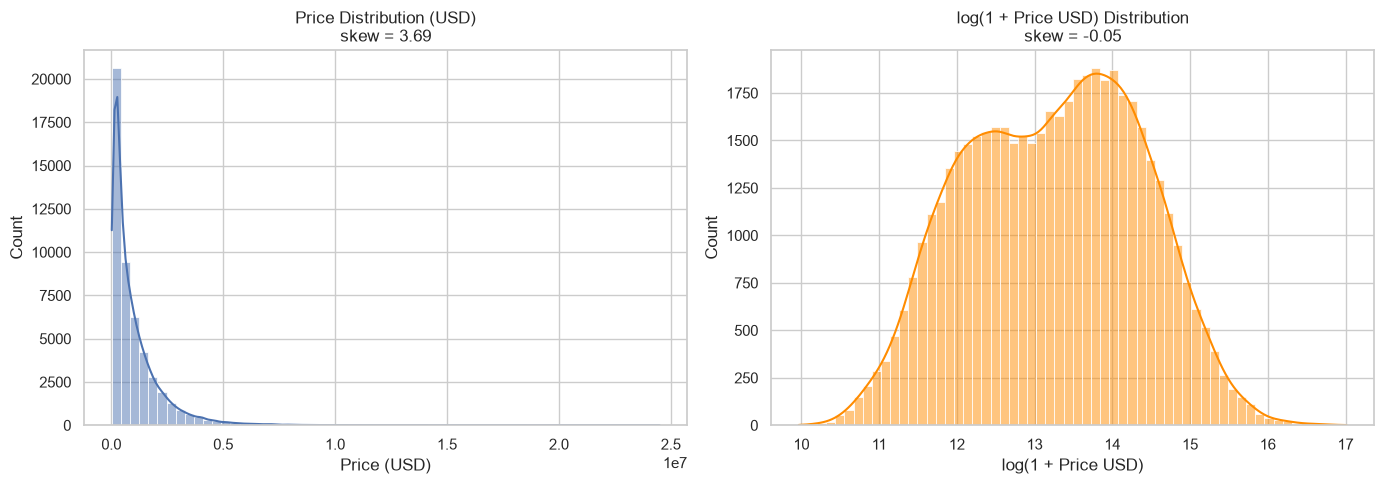

Raw price_usd skew: 3.692
log1p(price_usd) skew: -0.046


In [6]:
price_skew = df["price_usd"].skew()
log_price_skew = np.log1p(df["price_usd"]).skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price_usd"], bins=60, kde=True, ax=axes[0])
axes[0].set_title(f"Price Distribution (USD)\nskew = {price_skew:.2f}")
axes[0].set_xlabel(PRICE_LABEL)

sns.histplot(np.log1p(df["price_usd"]), bins=60, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title(f"log(1 + Price USD) Distribution\nskew = {log_price_skew:.2f}")
axes[1].set_xlabel("log(1 + Price USD)")

plt.tight_layout()

IMAGES_DIR.mkdir(exist_ok=True)
fig.savefig(IMAGES_DIR / "target_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Raw price_usd skew: {price_skew:.3f}")
print(f"log1p(price_usd) skew: {log_price_skew:.3f}")


**Observations:**
- Raw `price_usd` has a skew of **3.69** — heavily right-skewed, driven by a long   tail of luxury listings (already investigated and confirmed legitimate in   `01_data_cleaning.ipynb`, e.g. Bulgari Resort, Jumeirah Bay Island).
- After a `log1p` transform, skew drops to **-0.05** — essentially symmetric. This is   strong evidence that **training on `log(price_usd)` rather than raw `price_usd`**   will be worth testing in `03_modeling.ipynb` (per blueprint Part 16, Improvement   2), since linear-model assumptions and error metrics behave much better on a   roughly normal target.
- **Business implication:** most Dubai secondary-market listings in this dataset   cluster in the affordable-to-mid-market range, with a small number of extreme   luxury outliers pulling the mean (\$1.01M) well above the median (\$593,700).   Reporting a single "average Dubai property price" without median/skew context   would be misleading.
- **Image exported:** `images/target_price_distribution.png` (1 of 3 for the README).

This confirms the outlier-retention decision made in the cleaning phase: these are not errors to be removed, but the exact shape of skew a log transform is meant to address.


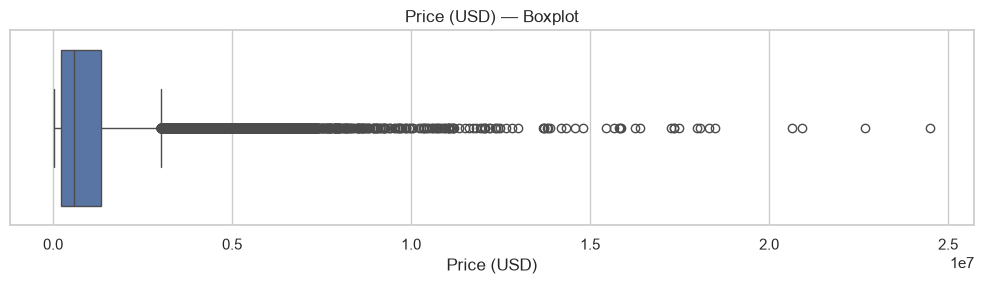

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df["price_usd"], ax=ax)
ax.set_xlabel(PRICE_LABEL)
ax.set_title("Price (USD) — Boxplot")
plt.tight_layout()
plt.show()


**Observation:** the boxplot visually confirms a dense interquartile range (~\$230K–\$1.34M) with a long right whisker of high-value outliers extending past \$20M. As established in the cleaning phase, these are retained as genuine luxury market observations, not data errors.


## 5. Categorical Feature Analysis

### 5.1 Property Type


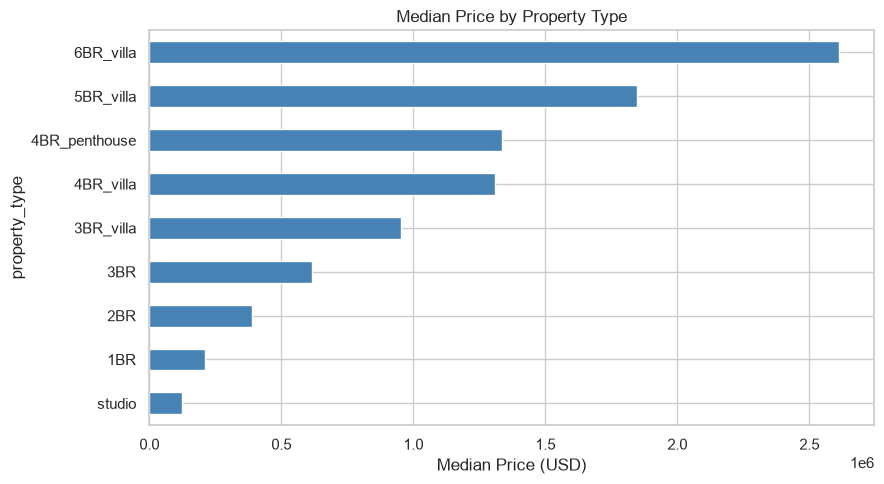

In [8]:
type_price = df.groupby("property_type")["price_usd"].median().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
type_price.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel(f"Median {PRICE_LABEL}")
ax.set_title("Median Price by Property Type")
plt.tight_layout()
plt.show()


**Observation:** median price scales cleanly with property type from `studio` (\$125,250) up to `6BR_villa` (\$2,614,200) — roughly a **21x spread**. Villas occupy the top of the ranking as expected, but `4BR_penthouse` (\$1,337,200) is notable: it slightly **outranks** `4BR_villa` (\$1,309,100), showing that within a given bedroom count, an apartment's *sub-type* (penthouse vs. standard) can flip the usual "villas cost more than apartments" pattern. This is a useful signal for feature engineering: `property_type` carries information that `property_category` and `bedrooms` alone do not.


### 5.2 Location — Community / Zone


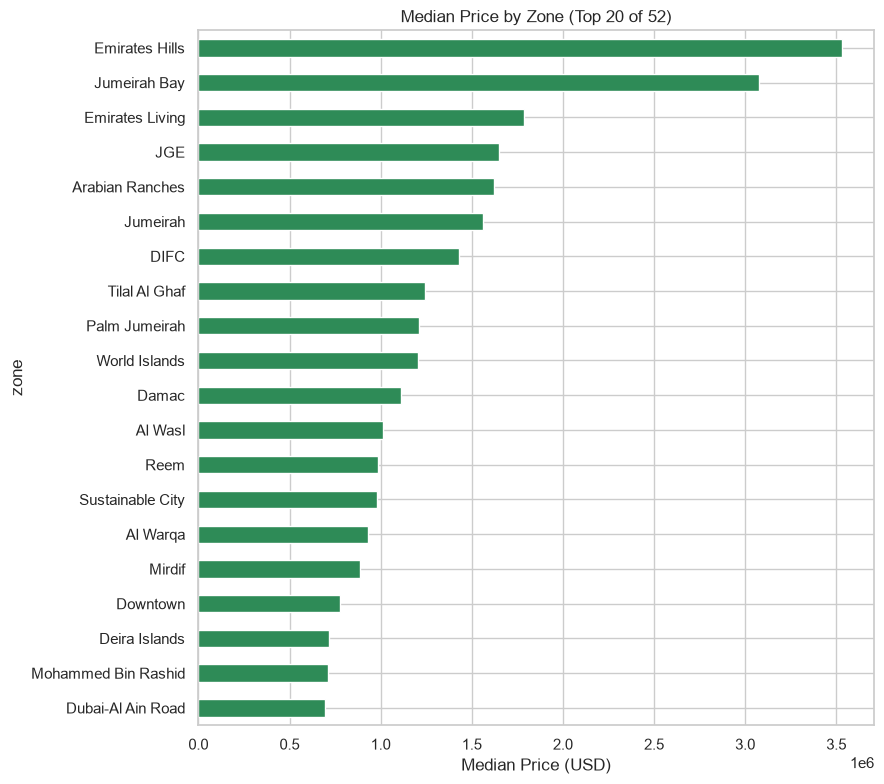

In [9]:
zone_price = df.groupby("zone")["price_usd"].median().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 8))
zone_price.sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.set_xlabel(f"Median {PRICE_LABEL}")
ax.set_title("Median Price by Zone (Top 20 of 52)")
plt.tight_layout()

fig.savefig(IMAGES_DIR / "median_price_by_zone.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
zone_stats = df.groupby("zone")["price_usd"].agg(["median", "count"]).sort_values("median", ascending=False)
print("Most expensive zone:", zone_stats.index[0], f"(median {PRICE_LABEL.lower()} = ${zone_stats.iloc[0]['median']:,.0f})")
print("Least expensive zone:", zone_stats.index[-1], f"(median {PRICE_LABEL.lower()} = ${zone_stats.iloc[-1]['median']:,.0f})")
print(f"Ratio: {zone_stats.iloc[0]['median'] / zone_stats.iloc[-1]['median']:.1f}x")


Most expensive zone: Emirates Hills (median price (usd) = $3,530,400)
Least expensive zone: International City (median price (usd) = $115,250)
Ratio: 30.6x


**Observation:** location is a dominant price driver. `Emirates Hills` tops the ranking at a **\$3,530,400** median, while `International City` sits at the bottom at **\$115,250** — a **~30.6x spread** between the most and least expensive zones. Interestingly, `Palm Jumeirah` (\$1,207,750 median) ranks below `Emirates Hills` and `Jumeirah Bay` here, which would be unusual in the real Dubai market where Palm Jumeirah typically commands some of the highest prices. This reinforces the synthetic-data documentation from the cleaning report: **zone-price relationships in this dataset should be treated as this dataset's own internal structure, not assumed to mirror real-world Dubai neighbourhood hierarchies.**
- **Image exported:** `images/median_price_by_zone.png` (2 of 3 for the README).


### 5.3 Furnishing Status


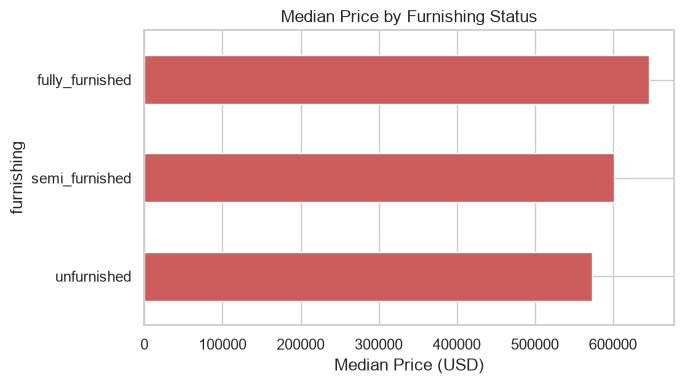

In [11]:
furnishing_price = df.groupby("furnishing")["price_usd"].median().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
furnishing_price.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel(f"Median {PRICE_LABEL}")
ax.set_title("Median Price by Furnishing Status")
plt.tight_layout()
plt.show()


**Observation:** furnishing status shows a real but modest effect — `fully_furnished` (\$646,000) commands roughly a **13% premium** over `unfurnished` (\$573,700), with `semi_furnished` (\$601,800) in between. This is a much smaller effect than location or property type, suggesting furnishing alone is a secondary price driver rather than a primary one.


### 5.4 Developer / Building — Not Available; Substitute: Condition

`secondary_sales.csv` has no `developer` or `building` column (that information only exists in the separate `off_plan.csv`, which is out of scope for this model version). As the closest available categorical proxy, we examine `condition` (`vacant_on_transfer`, `tenanted`, `off_plan_resale`).


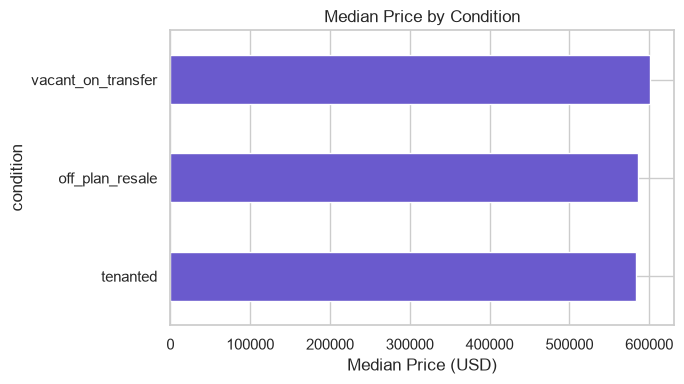

In [12]:
condition_price = df.groupby("condition")["price_usd"].median().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
condition_price.plot(kind="barh", ax=ax, color="slateblue")
ax.set_xlabel(f"Median {PRICE_LABEL}")
ax.set_title("Median Price by Condition")
plt.tight_layout()
plt.show()


**Observation:** unlike furnishing or property type, `condition` shows almost no price effect — medians range narrowly from \$583,000 (`tenanted`) to \$601,000 (`vacant_on_transfer`), a difference of about 3%. This suggests `condition` carries little standalone predictive signal for price in this dataset, and is a lower priority candidate for feature engineering than location or property type.


## 6. Numeric Feature Analysis

### 6.1 Area


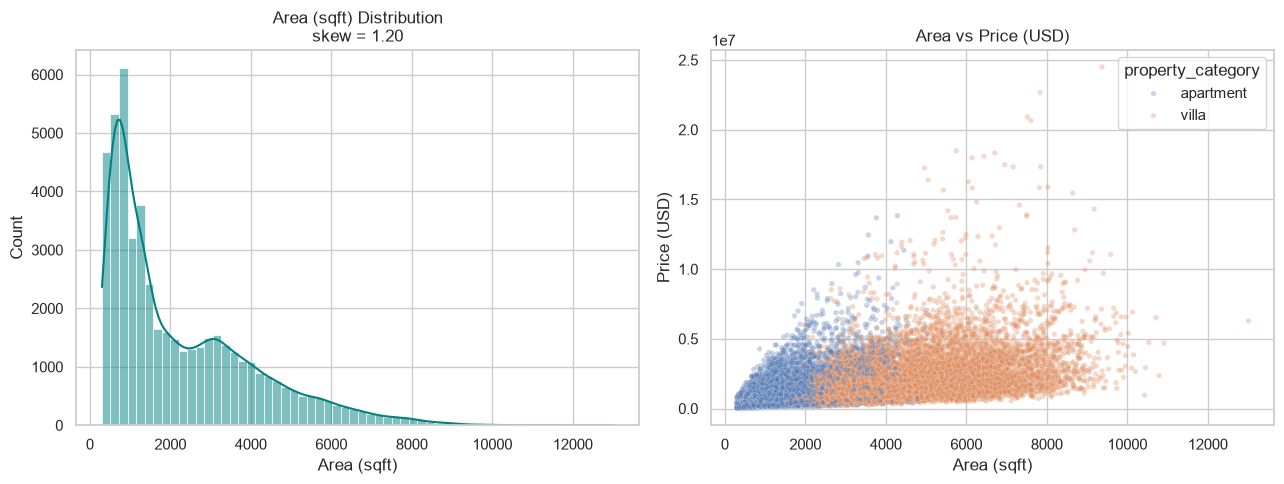

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["area_sqft"], bins=60, kde=True, ax=axes[0], color="teal")
axes[0].set_title(f"Area (sqft) Distribution\nskew = {df['area_sqft'].skew():.2f}")
axes[0].set_xlabel("Area (sqft)")

sns.scatterplot(data=df, x="area_sqft", y="price_usd", hue="property_category", alpha=0.3, s=15, ax=axes[1])
axes[1].set_title("Area vs Price (USD)")
axes[1].set_xlabel("Area (sqft)")
axes[1].set_ylabel(PRICE_LABEL)

plt.tight_layout()
plt.show()


**Observation:** `area_sqft` is itself right-skewed (skew 1.20) but far less extreme than price. The area-vs-price scatter shows a clear positive relationship for both apartments and villas, but with meaningfully different slopes and spread — apartments show a tighter, steeper size-price relationship (correlation 0.58) than villas (correlation 0.48), meaning **villa prices are driven by more than size alone** (location, view, and bedroom count likely contribute more for villas). This matters for feature engineering: `area_sqft` should probably interact with `property_category` rather than being treated as a single global linear effect.


### 6.2 Bedrooms


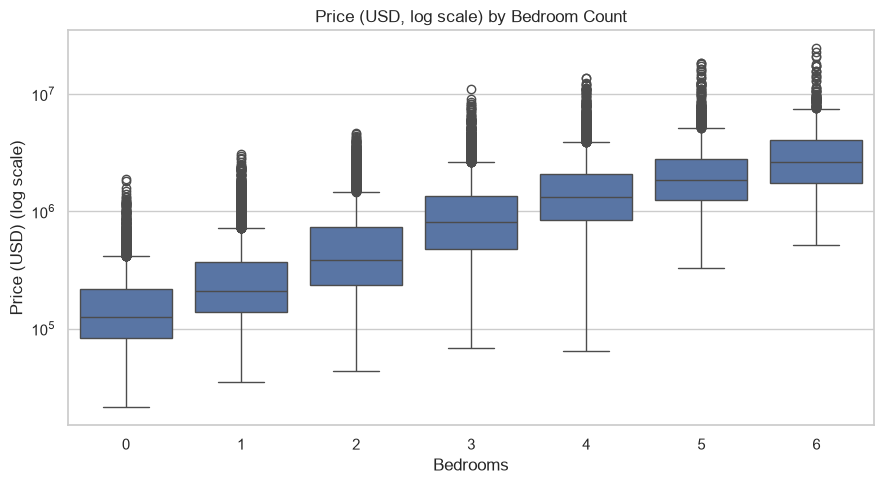

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="bedrooms", y="price_usd", ax=ax)
ax.set_yscale("log")
ax.set_ylabel(f"{PRICE_LABEL} (log scale)")
ax.set_xlabel("Bedrooms")
ax.set_title("Price (USD, log scale) by Bedroom Count")
plt.tight_layout()
plt.show()


In [15]:
df.pivot_table(index="bedrooms", columns="property_category", values="price_usd", aggfunc="median")


property_category,apartment,villa
bedrooms,,
0,125250.0,NaN
1,210500.0,NaN
2,387750.0,NaN
3,615600.0,954700.0
4,1337200.0,1309100.0
5,NaN,1848300.0
6,NaN,2614200.0


**Observation:** median price increases monotonically with bedroom count (\$125,250 for studios up to \$2,614,200 for 6-bedroom villas). However, the pivot table above reveals a crossover: at 4 bedrooms, **apartments (\$1,337,200 median) slightly exceed villas (\$1,309,100 median)** — because every 4-bedroom apartment in this dataset is a `4BR_penthouse`, an ultra-premium subtype. This confirms bedroom count alone is not a clean linear price driver; it needs to be interpreted jointly with `property_type`/`property_category`, not in isolation.


### 6.3 Bathrooms — Not Available

There is **no `bathrooms` column** in `secondary_sales.csv`. This deviates from the project blueprint's assumption (which was written before this specific dataset was selected) and is documented here rather than fabricated. `bedrooms` and `area_sqft` are the available proxies for property specification/size in this dataset.


### 6.4 Floors


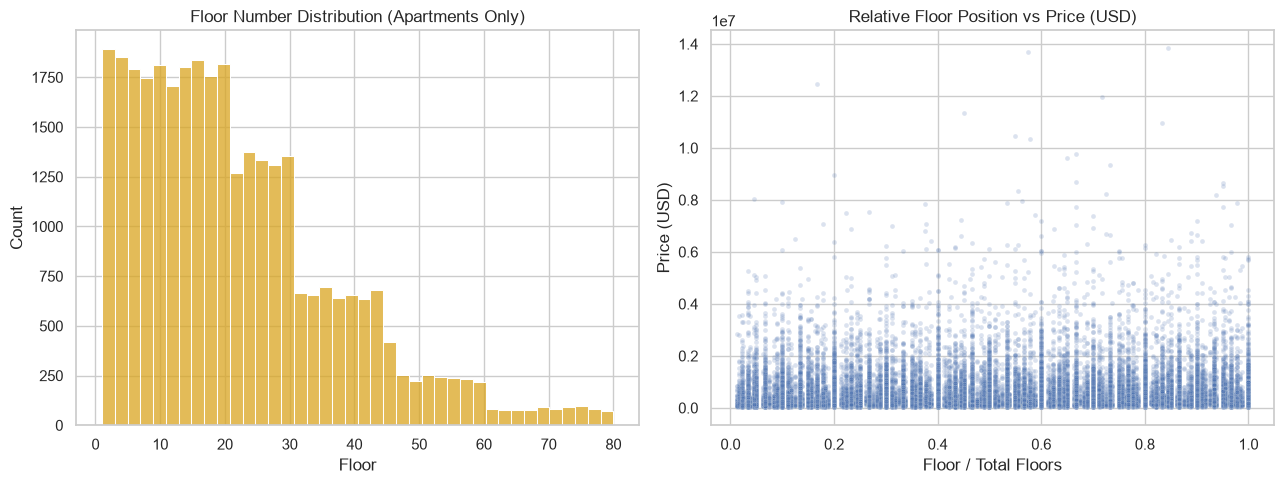

floor_ratio vs price_usd correlation (apartments only): 0.04
floor vs price_usd correlation (apartments only): 0.056


In [16]:
apartments = df[df["property_category"] == "apartment"].copy()
apartments["floor_ratio"] = apartments["floor"] / apartments["total_floors"]  # transient, for plotting only

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(apartments["floor"], bins=40, ax=axes[0], color="goldenrod")
axes[0].set_title("Floor Number Distribution (Apartments Only)")
axes[0].set_xlabel("Floor")

sns.scatterplot(data=apartments, x="floor_ratio", y="price_usd", alpha=0.2, s=12, ax=axes[1])
axes[1].set_title("Relative Floor Position vs Price (USD)")
axes[1].set_xlabel("Floor / Total Floors")
axes[1].set_ylabel(PRICE_LABEL)

plt.tight_layout()
plt.show()

print("floor_ratio vs price_usd correlation (apartments only):", round(apartments["floor_ratio"].corr(apartments["price_usd"]), 3))
print("floor vs price_usd correlation (apartments only):", round(apartments["floor"].corr(apartments["price_usd"]), 3))


**Observation:** floor position shows almost no relationship with price in this dataset — both absolute `floor` (correlation 0.056) and relative `floor_ratio` (correlation 0.040) are close to zero. This runs counter to common real-world intuition (higher floors often command a view/height premium); combined with the zone-ranking anomaly noted in Section 5.2, it further supports treating this dataset as **synthetically generated with simplified location/size-driven pricing**, rather than a fully realistic simulation of every real-world price driver. This is a useful finding for setting expectations about what the eventual model can and cannot learn: floor-level effects are not expected to be a meaningful predictor here, regardless of how they're engineered.


## 7. Relationship Analysis

### 7.1 Correlation Analysis


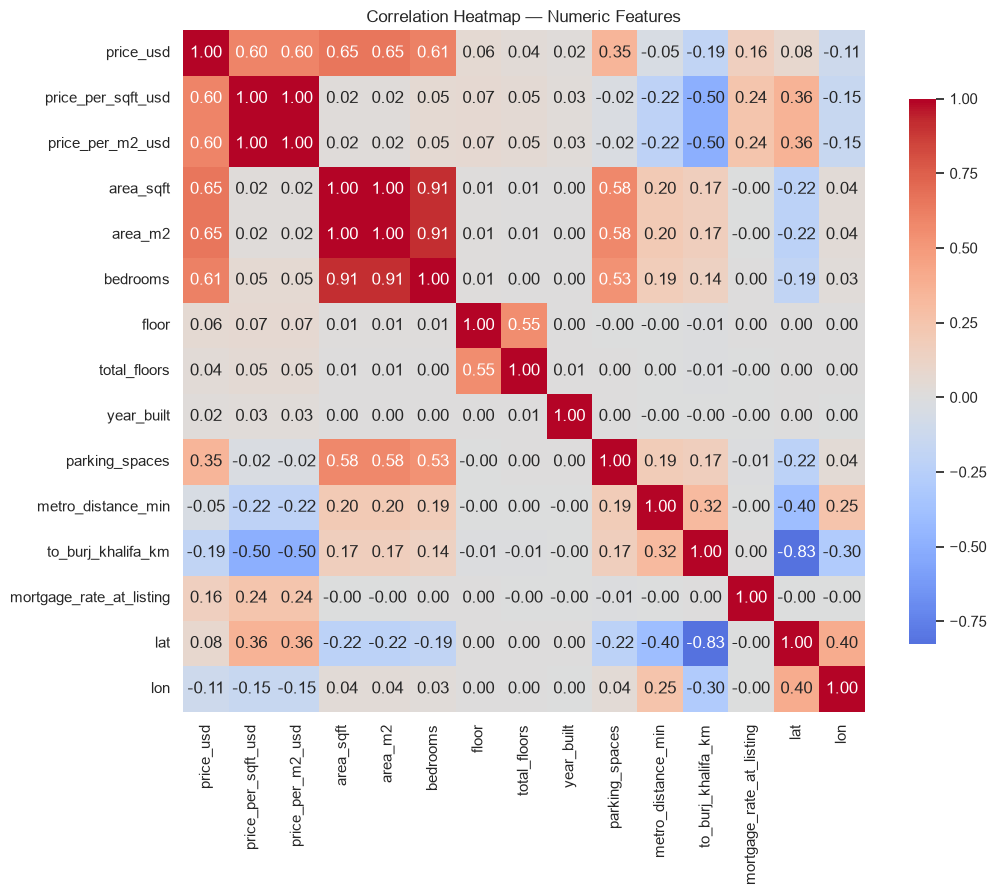

In [17]:
numeric_cols = [
    "price_usd", "price_per_sqft_usd", "price_per_m2_usd",
    "area_sqft", "area_m2", "bedrooms", "floor", "total_floors",
    "year_built", "parking_spaces", "metro_distance_min",
    "to_burj_khalifa_km", "mortgage_rate_at_listing", "lat", "lon",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()

fig.savefig(IMAGES_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
corr["price_usd"].drop("price_usd").sort_values(ascending=False)


area_m2                     0.653357
area_sqft                   0.653355
bedrooms                    0.609272
price_per_m2_usd            0.600719
price_per_sqft_usd          0.600715
parking_spaces              0.348998
mortgage_rate_at_listing    0.164676
lat                         0.084296
floor                       0.055887
total_floors                0.036198
year_built                  0.016614
metro_distance_min         -0.047479
lon                        -0.114947
to_burj_khalifa_km         -0.189896
Name: price_usd, dtype: float64

**Observation:** `price_per_sqft_usd` and `price_per_m2_usd` correlate at ~0.60 with `price_usd` — but this is a **trivial/leaky correlation**, since both columns are deterministically derived from `price_usd` itself (documented in the cleaning report). They must **not** be read as genuine predictive relationships, and must stay excluded from the model's feature set in `03_modeling.ipynb`.

Among genuine candidate features, `area_sqft`/`area_m2` (0.65) and `bedrooms` (0.61) are the strongest predictors, followed by `parking_spaces` (0.35) — a reasonable proxy for property size/specification tier not captured by area alone. `to_burj_khalifa_km` is mildly negative (-0.19), consistent with central Dubai commanding a premium. `floor`, `total_floors`, and `year_built` are all near-zero (<0.06), consistent with the floor-position finding above and suggesting building age is not a strong standalone driver in this dataset. `area_sqft` and `area_m2` are perfectly redundant (both derived from the same physical size) — only one should be kept as a model feature.
- **Image exported:** `images/correlation_heatmap.png` (3 of 3 for the README).


### 7.2 Property Type vs Price


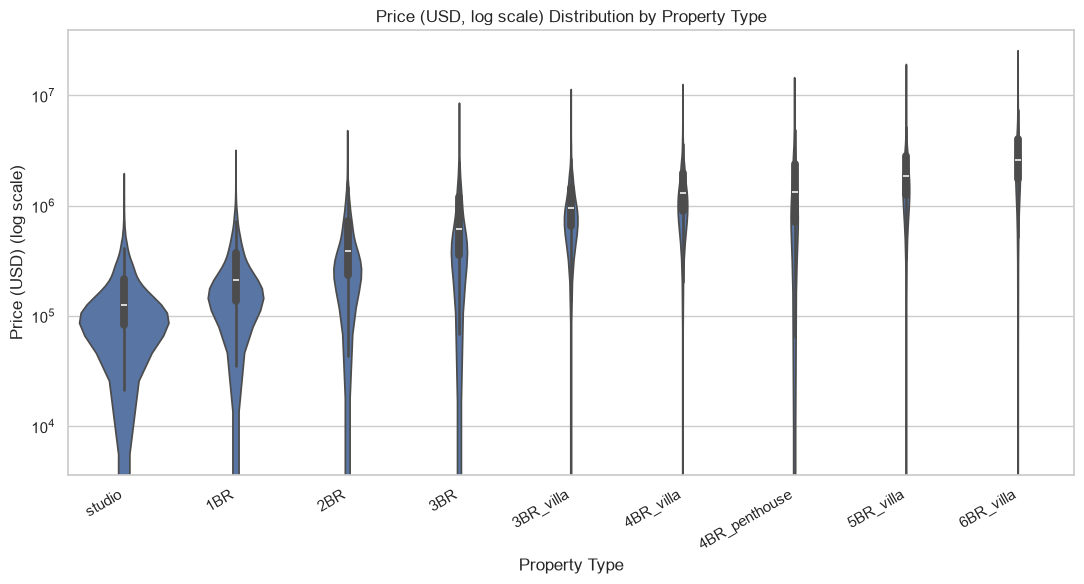

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
order = df.groupby("property_type")["price_usd"].median().sort_values().index
sns.violinplot(data=df, x="property_type", y="price_usd", order=order, ax=ax)
ax.set_yscale("log")
ax.set_ylabel(f"{PRICE_LABEL} (log scale)")
ax.set_xlabel("Property Type")
ax.set_title("Price (USD, log scale) Distribution by Property Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Observation:** the violin plot shows not just the median shift across property types (already seen in Section 5.1) but also that **spread increases with property tier** — `studio` and `1BR` listings are tightly clustered, while `5BR_villa` and `6BR_villa` show much wider price distributions. This suggests prediction error is likely to be larger in dirham (or dollar) terms for higher-end properties, an expectation worth revisiting during model error analysis in `03_modeling.ipynb`.


### 7.3 Location x Property Type Interaction


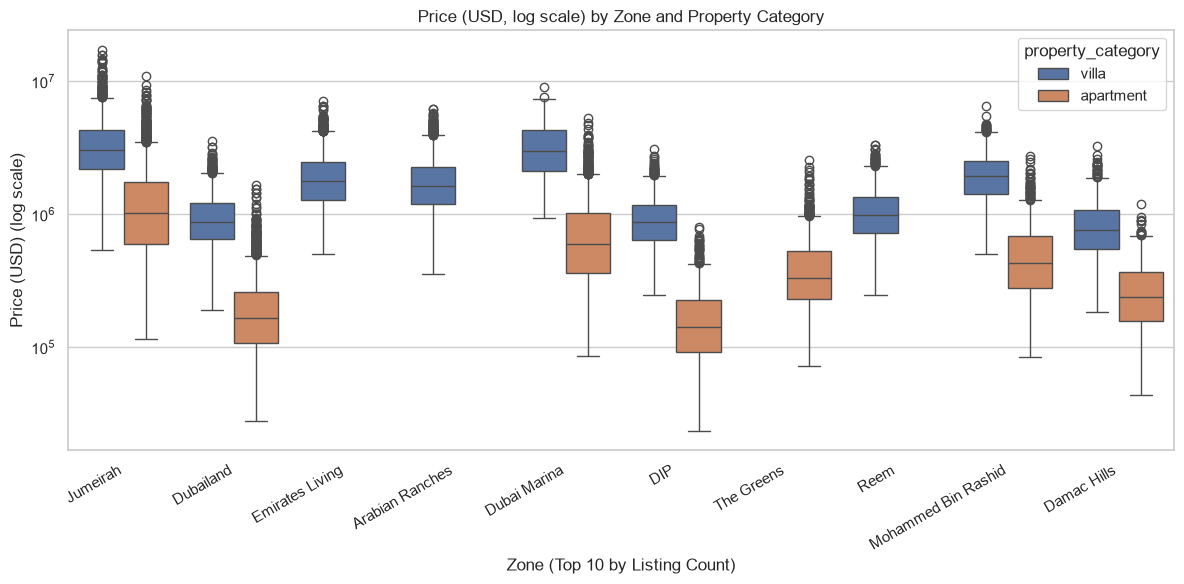

In [20]:
top_zones = df["zone"].value_counts().head(10).index
subset = df[df["zone"].isin(top_zones)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=subset, x="zone", y="price_usd", hue="property_category", order=top_zones, ax=ax)
ax.set_yscale("log")
ax.set_ylabel(f"{PRICE_LABEL} (log scale)")
ax.set_xlabel("Zone (Top 10 by Listing Count)")
ax.set_title("Price (USD, log scale) by Zone and Property Category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Observation:** within every one of the top 10 zones by listing volume, villas consistently price above apartments — the location effect and the property-category effect are **additive, not confounded**: knowing both a property's zone and its category is more informative than either alone. This supports engineering a `zone x property_category` interaction (or an equivalent location-tier x category feature) in the modeling phase, per the blueprint's Part 21 guidance.


### 7.4 Multivariate — Top Numeric Features by Property Category


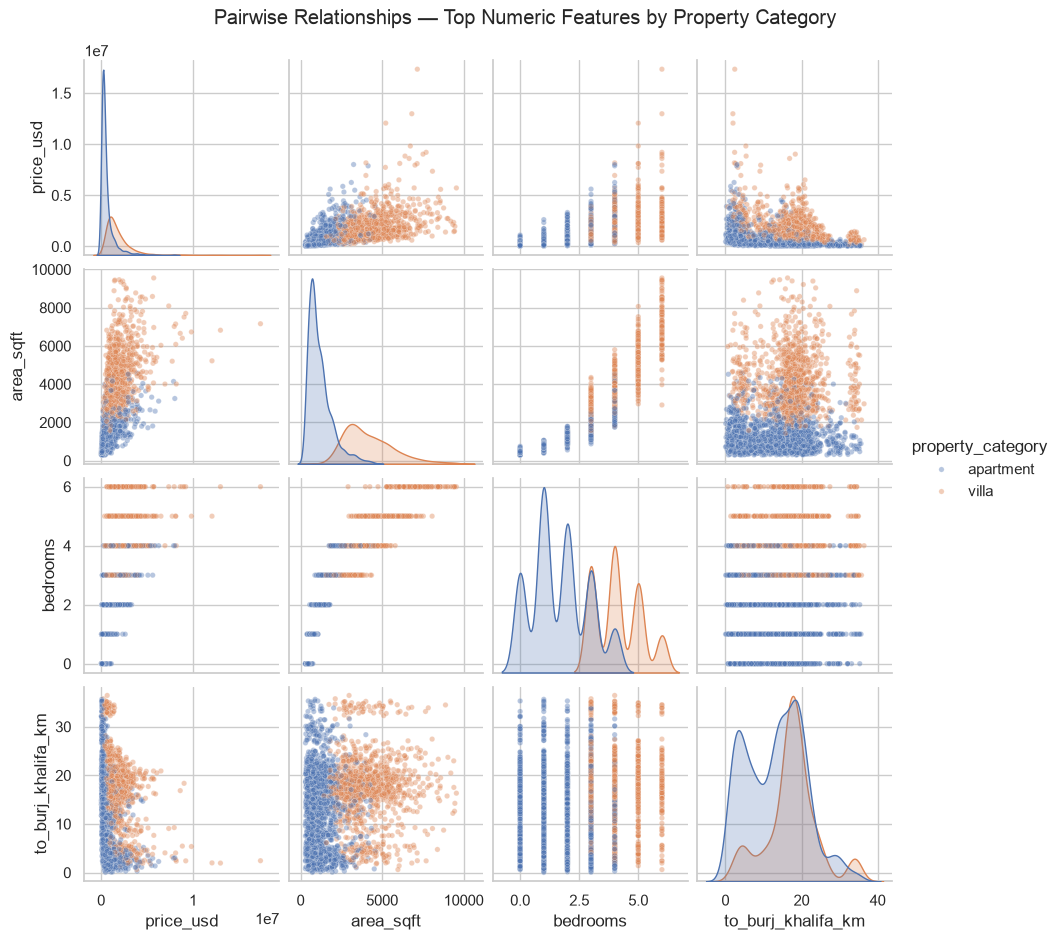

In [21]:
pairplot_features = ["price_usd", "area_sqft", "bedrooms", "to_burj_khalifa_km"]
sample = df.sample(n=3000, random_state=RANDOM_STATE)

g = sns.pairplot(sample, vars=pairplot_features, hue="property_category", plot_kws={"alpha": 0.4, "s": 15}, height=2.3)
g.fig.suptitle("Pairwise Relationships — Top Numeric Features by Property Category", y=1.02)
plt.show()


**Observation:** we plot a random 3,000-row sample (fixed `RANDOM_STATE = 42`) purely for rendering speed and visual clarity — this does not modify or persist any data; the full 50,000-row dataset is used everywhere else. We color by `property_category` (2 groups) rather than the blueprint's suggested `property_type` (9 groups): with a scatter-matrix at this density, 9 overlapping colors would be unreadable, while apartment-vs-villa is exactly the split we already found to be the most structurally important (Sections 6.1, 6.2, 7.3). The pairplot reinforces the same pattern seen throughout: villas and apartments form two visually distinct clusters across `area_sqft` and `price_usd`, while `to_burj_khalifa_km` shows a weaker, noisier separation between the two groups.


## 8. Summary — Findings and Recommendations

### Findings about the Dubai property market patterns in this dataset

1. **Price is heavily right-skewed** (skew 3.69) but becomes near-symmetric after a    `log1p` transform (skew -0.05) — strong evidence for modeling `log(price_usd)`.
2. **Location is the single strongest categorical driver of price**: median price    ranges from \$115,250 (International City) to \$3,530,400 (Emirates Hills), a    ~30.6x spread across zones.
3. **Property type explains a ~21x price spread** on its own (studio \$125,250 →    6BR villa \$2,614,200), independent of location.
4. **Villas are far more expensive than apartments overall** (median \$1,404,650 vs    \$305,050, ~4.6x), and this holds consistently within every major zone (Section    7.3) — the effects are additive, not confounded.
5. **Bedroom count is not a clean linear driver in isolation** — at 4 bedrooms,    `4BR_penthouse` apartments (\$1,337,200 median) actually exceed `4BR_villa`    (\$1,309,100), because that apartment sub-type is exclusively an ultra-premium    category.
6. **Area size matters more for apartments (r=0.58) than for villas (r=0.48)** —    villa pricing is driven more by non-size factors (location, view, bedroom tier).
7. **View type carries a real, substantial price premium**: sea-view listings    (\$1,173,550 median) price more than 2.5x above community-view listings    (\$438,700 median).
8. **Freehold status correlates with a large price gap** (\$669,200 vs \$264,700    median for non-freehold) — largely because freehold zones tend to be the more    premium areas, not a standalone causal effect.
9. **Furnishing status has a real but modest effect** (~13% premium for fully    furnished vs. unfurnished) — a secondary, not primary, price driver.
10. **`condition` (vacant/tenanted/off-plan-resale) shows almost no price effect**     (~3% spread) — the weakest categorical signal examined.
11. **Floor position within a building shows essentially no relationship with     price** (correlation ~0.04-0.06), which is unusual relative to real-world Dubai     market intuition and is best explained by this dataset being synthetically     generated rather than fully simulating every real-world price driver.
12. **`parking_spaces` correlates surprisingly strongly with price** (r=0.35) —     likely acting as a proxy for overall property specification/tier rather than a     causal driver in its own right.
13. **`price_per_sqft_usd`/`price_per_m2_usd` correlations with price (~0.60) are     not genuine relationships** — they are algebraically derived from the target     and must be excluded from the model's feature set.
14. **Zone-level price rankings in this dataset do not fully mirror real-world Dubai     submarket hierarchies** (e.g. Palm Jumeirah ranks below Emirates Hills and     Jumeirah Bay here) — a limitation to state explicitly in the README rather than     imply this reflects the real Bayut/Dubizzle market.

### Recommendations for feature engineering (next phase, `03_modeling.ipynb`)

- Train on **`log1p(price_usd)`** as the primary target, evaluating whether it   improves model fit and error-metric interpretability versus raw `price_usd`.
- Build a **location tier feature from `zone`**, data-driven (e.g. quantile-binning   zones by median price) rather than assuming real-world Dubai submarket knowledge,   since this dataset's zone-price hierarchy has already been shown not to fully   match real-world patterns.
- Create a **`zone x property_category` (or location-tier x category) interaction   feature**, since Section 7.3 showed these effects are additive across all major   zones.
- Keep `area_sqft` **or** `area_m2`, not both — they are perfectly redundant.
- Explicitly **exclude `price_per_sqft_usd` and `price_per_m2_usd`** from the model   feature set (retain only for post-hoc evaluation benchmarking, per the cleaning   report).
- Build a **`has_floor_info` flag from `property_category`** to make the villa   floor-missingness explicit to the model, rather than relying on raw `NaN`   handling alone.
- Given `floor`/`floor_ratio` show negligible correlation with price, treat them as   **low-priority** engineering candidates — don't over-invest engineering effort   here relative to location and property-type features.
- Consider a **`property_age`** feature (`year(date_listed) - year_built`), even   though `year_built`'s raw correlation with price is weak (0.017) — age may   interact with location or type rather than act as a standalone linear driver,   worth testing rather than discarding outright.
- Given `bathrooms` doesn't exist in this dataset, any spec-suggested   `bedroom_bathroom_ratio` feature is **not applicable** and should be dropped from   the modeling plan rather than approximated.

**Next notebook:** `03_modeling.ipynb` — feature engineering, baseline model, and trained model comparison.
